# V768 - Measuring Vision with Psychophysics

## Lab 9 - Continuous Psychophysics

In previous labs, you've measured visual perception using forced choice experiments that involve showing one or more stimuli to an observer and then obtaining one discrete response.

What if we instead wanted to measure an observer's perception <u>***continuously***</u>?

In this lab, you'll learn how **continuous psychophysics** can be used to measure perception throughout a trial. Specifically, you'll learn how to analyze data from a continuous target-tracking task, and you'll assess the validity of that task by comparing the results to those of a more traditional forced choice experiment.

### Learning Outcomes

(i.e., what you will be able to do at the end of this lab)

- Describe a target-tracking experiment from the perspective of a subject.

- Compare and contrast target-tracking experiments and 2AFC experiments using the matched experiments in this lab as examples.

### Questions

- Include and write a caption for the figure in Part A, Step 3. Visualize trial data, "Plot the target and response positions for an example trial" (3-panel figure showing example position data).

- Include and write a caption for the figure in Part A, Step 4. Analyze your data, "Plot CCGs per stimulus condition" (2-panel figure with 4 lines per panel).

- Include and write a caption for the figure in Part A, Step 4. Analyze your data, "Calculate and plot response latency".

- Include and write a caption for the figure in Part B, Step 4. Analyze your data, "Calculate and plot just noticeable difference (JND)".

- Include and write a caption for the figure in Part C. Performance Comparison.

- Do you think these experiments are measuring the same thing? Why or why not?

- Discuss the pros and cons of these two types of tasks.

## Part A. Continuous Target-Tracking

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "tracking", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 16 trials.

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [28]:
from pathlib import Path
from statistics import NormalDist
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psignifit as ps
except ImportError:
    ps = None

rng = np.random.default_rng(2025)


def normcdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.cdf, otypes=[float])(x)


def norminv(p, mu, sigma):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, np.finfo(float).eps, 1 - np.finfo(float).eps)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.inv_cdf, otypes=[float])(p)


def psyfxn(c, x):
    c = np.asarray(c, dtype=float)
    return (normcdf(x, c[0], c[1]) * (1 - c[2] - c[3])) + c[2]


def ipsyfxn(c, p):
    c = np.asarray(c, dtype=float)
    return norminv((np.asarray(p, dtype=float) - c[2]) / (1 - c[2] - c[3]), c[0], c[1])


def fit_psignifit(data, experiment_type="yes/no"):
    if ps is None:
        raise ImportError("psignifit is required for psychometric fitting. Install it with: pip install psignifit")
    try:
        return ps.psignifit(data, experiment_type=experiment_type, sigmoid="norm")
    except TypeError:
        exp_type = "YesNo" if experiment_type.lower() in {"yes/no", "yesno", "yes-no"} else experiment_type
        options = {"expType": exp_type, "sigmoidName": "norm"}
        return ps.psignifit(data, options)


def psignifit_parameter_array(result, fallback_gamma=0.0, fallback_lambda=0.0):
    if hasattr(result, "parameter_estimate"):
        params = result.parameter_estimate
        try:
            mu, sigma = result.standard_parameter_estimate()
        except Exception:
            mu = params.get("threshold", np.nan)
            sigma = params.get("width", np.nan)
        return np.array([
            mu,
            sigma,
            params.get("gamma", fallback_gamma),
            params.get("lambda", fallback_lambda),
        ], dtype=float)

    if isinstance(result, dict):
        fit = np.asarray(result["Fit"], dtype=float)
        # psignifit 4 order is commonly [threshold, width, lambda, gamma, eta].
        return np.array([
            fit[0],
            fit[1],
            fit[3] if fit.size > 3 else fallback_gamma,
            fit[2] if fit.size > 2 else fallback_lambda,
        ], dtype=float)

    raise TypeError("Could not read fitted parameters from this psignifit result object.")


def psignifit_predict(result, x, params=None):
    x = np.asarray(x, dtype=float)
    if hasattr(result, "proportion_correct"):
        return np.asarray(result.proportion_correct(x), dtype=float)
    if params is None:
        params = psignifit_parameter_array(result)
    return psyfxn(params, x)


def find_participant_files(data_dir, participant_id):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(
            "PsychoPy data folder not found. Try changing your current Python "
            "folder to the folder containing this notebook."
        )
    file_paths = sorted(path for path in data_dir.glob(f"{participant_id}*.csv") if path.name.startswith(participant_id))
    if not file_paths:
        raise FileNotFoundError("No files found.")
    file_info = pd.DataFrame({
        "name": [path.name for path in file_paths],
        "folder": [str(path.parent) for path in file_paths],
        "path": file_paths,
    })
    print("data files found:")
    for name in file_info["name"]:
        print(f'    "{name}"')
    return file_info


def load_psychopy_csvs(file_info, remove_instruction_rows=True):
    frames = []
    for path in file_info["path"]:
        this_data = pd.read_csv(path)
        if remove_instruction_rows:
            if "thisN" in this_data.columns:
                this_data = this_data[this_data["thisN"].notna()]
            elif "trials.thisN" in this_data.columns:
                this_data = this_data[this_data["trials.thisN"].notna()]
            else:
                this_data = this_data.iloc[1:]
        frames.append(this_data.reset_index(drop=True))
    data = pd.concat(frames, ignore_index=True)
    data = data.drop(columns=["notes", "begin_experiment.started", "begin_experiment.stopped"], errors="ignore")
    return data


def display_fit_table(params, columns=("fit",)):
    return pd.DataFrame(
        np.asarray(params).reshape(4, -1),
        index=["mu", "sigma", "gamma", "lambda"],
        columns=list(columns),
    )
import ast


def parse_vector(value):
    if isinstance(value, str):
        value = value.strip()
        if not value or value.lower() == "nan":
            return np.array([], dtype=float)
        return np.asarray(ast.literal_eval(value), dtype=float)
    return np.array([], dtype=float)


def normpdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def normalized_xcorr(x, y, max_lag):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    denom = np.sqrt(np.sum(x ** 2) * np.sum(y ** 2))
    full = np.correlate(x, y, mode="full") / denom if denom else np.zeros(len(x) + len(y) - 1)
    full_lags = np.arange(-len(y) + 1, len(x))
    desired_lags = np.arange(-max_lag, max_lag + 1)
    return np.interp(desired_lags, full_lags, full, left=np.nan, right=np.nan)

participant_id = "demo"

# check current working directory and find files
file_info = find_participant_files(Path("tracking") / "data", participant_id)
n_files = len(file_info)


data files found:
    "demo_tracking_2025-03-25_00h18.59.732.csv"


**Confirm that all of your data files are listed above.** There should be <u>one</u> file.

#### Load and merge data tables


In [29]:
# load data and stack it into one table
track_data = load_psychopy_csvs(file_info)

# display data table size
n_trials = len(track_data)
print(f"number of trials = {n_trials}")


number of trials = 16


### Step 3. Visualize trial data

For this experiment, the stimulus was a two-dimensional Gaussian luminance blob that moved across the screen in a random walk. Across trials, the blob's width varied. (Because the contrast of these blobs depends on their width, contrast also varied.) The participant was tasked with tracking the center of the blob by moving a red dot around the screen with their mouse or trackpad.

For each trial, PsychoPy saved several timecourses (i.e., sets of data per time point): the time in seconds, the target's x and y coordinates in pixels, and the response cursor's x and y coordinates in pixels. Additionally, the blob width per trial was saved.


In [30]:
# extract the target and response positions
target_x = [parse_vector(value) for value in track_data["blob.x"]]
target_y = [parse_vector(value) for value in track_data["blob.y"]]
response_x = [parse_vector(value) for value in track_data["response_mouse.x"]]
response_y = [parse_vector(value) for value in track_data["response_mouse.y"]]

# extract the time of each data point
track_time = [parse_vector(value) for value in track_data["response_mouse.time"]]

# extract the blob width
target_width = track_data["blobWidth"].astype(float).to_numpy()


#### Plot the target and response positions for an example trial

To get a sense of what the data for one trial look like, let's plot the coordinates of the stimulus and response three ways: (1) in xy space, (2) x-position vs. time, and (3) y-position vs. time.


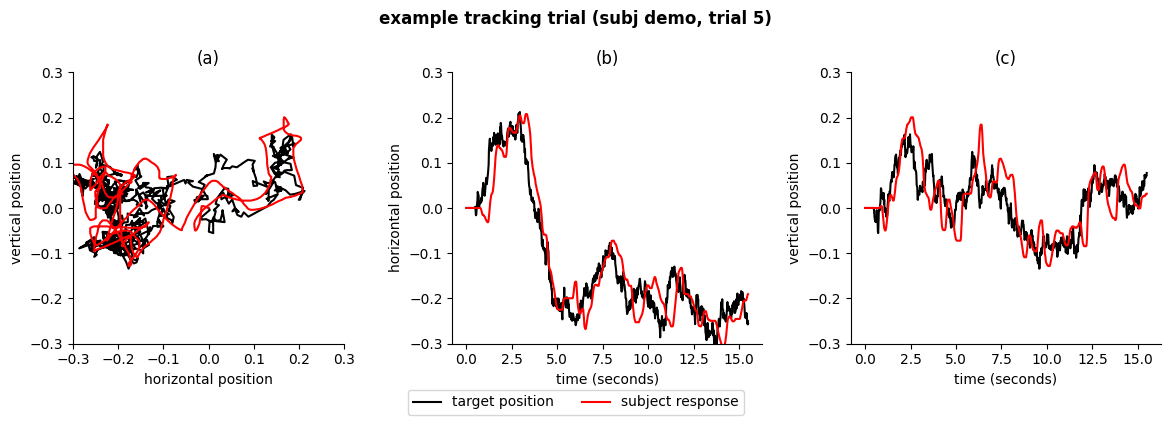

In [31]:
pick_a_trial = 5  # choose which trial to plot
pick_idx = pick_a_trial - 1

# plot!
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f"example tracking trial (subj {participant_id}, trial {pick_a_trial})", fontweight='bold')
line_width = 1.5

ax = axes[0]
ax.plot(target_x[pick_idx], target_y[pick_idx], 'k', linewidth=line_width)
ax.plot(response_x[pick_idx], response_y[pick_idx], 'r', linewidth=line_width)
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.3, 0.3)
ax.set_aspect('equal', adjustable='box')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title("(a)")
ax.set_xlabel("horizontal position")
ax.set_ylabel("vertical position")

ax = axes[1]
ax.plot(track_time[pick_idx], target_x[pick_idx], 'k', linewidth=line_width)
ax.plot(track_time[pick_idx], response_x[pick_idx], 'r', linewidth=line_width)
ax.set_ylim(-0.3, 0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title("(b)")
ax.set_xlabel("time (seconds)")
ax.set_ylabel("horizontal position")

ax = axes[2]
ax.plot(track_time[pick_idx], target_y[pick_idx], 'k', linewidth=line_width, label="target position")
ax.plot(track_time[pick_idx], response_y[pick_idx], 'r', linewidth=line_width, label="subject response")
ax.set_ylim(-0.3, 0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title("(c)")
ax.set_xlabel("time (seconds)")
ax.set_ylabel("vertical position")
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.show()


When we show a participant a stimulus, we always expect there to be a time gap before their response because perceiving a stimulus, deciding how to respond, and moving to respond each take time (not necessarily very much time, but more than nothing). A participant could only reliably respond to a stimulus before they actually see it if the stimulus's state is predictable. In this case, the target's motion was random, so we can be confident that there should be a temporal delay (lag) between the target's motion and the response cursor's motion (i.e., the response should lag behind the target in time).

Because of this expected temporal delay, the lines plotted above will likely not match exactly, but if the participant was very good at tracking the target with their cursor, the shape of the plotted lines will look fairly similar. We ultimately want to quantify the participant's ability to track the target, so take a moment to consider the trial data plotted above and ask yourself, **how can we quantify the similarity between the target and response data?**

#### Plot the target velocities for an example trial

First, let's confirm that our target's motion was random. The experiment was designed such that the stimulus **velocity** at each time point should have been randomly sampled from a normal distribution with a mean of zero. We can confirm that the velocities are normally distributed by plotting their actual distribution along with the distribution from which they should have been drawn.


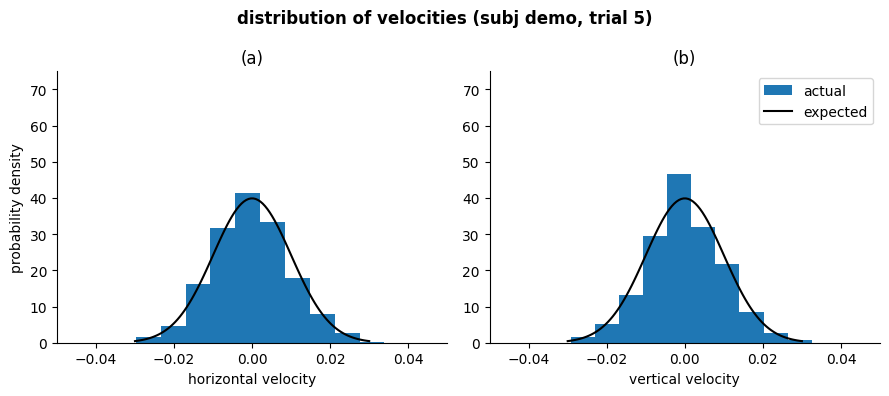

In [32]:
# get expected distribution of velocity values
vel_pdf = SimpleNamespace()
vel_pdf.sigma = float(track_data["sig"].iloc[0])
vel_pdf.x = np.linspace(-3 * vel_pdf.sigma, 3 * vel_pdf.sigma, 100)
vel_pdf.y = normpdf(vel_pdf.x, 0, vel_pdf.sigma)

# plot!
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle(f"distribution of velocities (subj {participant_id}, trial {pick_a_trial})", fontweight='bold')

axes[0].hist(np.diff(target_x[pick_idx]), density=True)
axes[0].plot(vel_pdf.x, vel_pdf.y, 'k', linewidth=line_width)
axes[0].set_xlim(-0.05, 0.05)
axes[0].set_ylim(0, 75)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title("(a)")
axes[0].set_xlabel("horizontal velocity")
axes[0].set_ylabel("probability density")

axes[1].hist(np.diff(target_y[pick_idx]), density=True, label="actual")
axes[1].plot(vel_pdf.x, vel_pdf.y, 'k', linewidth=line_width, label="expected")
axes[1].set_xlim(-0.05, 0.05)
axes[1].set_ylim(0, 75)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_title("(b)")
axes[1].set_xlabel("vertical velocity")
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()


**What do you think?** Were the actual velocities randomly drawn from the expected distribution?

#### Plot the target and response velocities for an example trial

Next, let's take a look at the velocity timecourses.


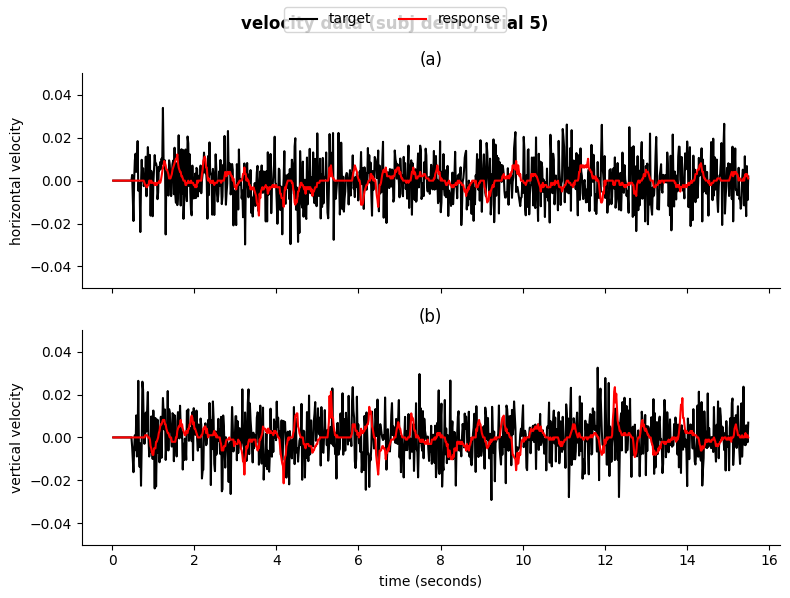

In [33]:
# get velocities for that trial
ex_vel = SimpleNamespace()
ex_vel.targ_x = np.diff(target_x[pick_idx])
ex_vel.targ_y = np.diff(target_y[pick_idx])
ex_vel.resp_x = np.diff(response_x[pick_idx])
ex_vel.resp_y = np.diff(response_y[pick_idx])
ex_vel.time = track_time[pick_idx][1:]

# plot!
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.suptitle(f"velocity data (subj {participant_id}, trial {pick_a_trial})", fontweight='bold')
line_width = 1.5

axes[0].plot(ex_vel.time, ex_vel.targ_x, 'k', linewidth=line_width, label="target")
axes[0].plot(ex_vel.time, ex_vel.resp_x, 'r', linewidth=line_width, label="response")
axes[0].set_ylim(-0.05, 0.05)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title("(a)")
axes[0].set_ylabel("horizontal velocity")

axes[1].plot(ex_vel.time, ex_vel.targ_y, 'k', linewidth=line_width)
axes[1].plot(ex_vel.time, ex_vel.resp_y, 'r', linewidth=line_width)
axes[1].set_ylim(-0.05, 0.05)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_title("(b)")
axes[1].set_xlabel("time (seconds)")
axes[1].set_ylabel("vertical velocity")
fig.legend(loc='upper center', ncol=2)
plt.tight_layout()
plt.show()


### Step 4. Analyze your data

Due to the randomness of the target's motion and the time required for the participant to perceive and respond to a visual stimulus, the movement of the response cursor should lag behind the movement of the target, even for the most accurate participant. To account for that lag, we can take the stimulus and response time series, shift the response time series backwards and forwards in time, and compute the similarity between the two time series as a function of that relative temporal shift. In other words, we can calculate the **cross-correlation** of the target and response data.

**Cross-correlation** measures the similarity between two series of values as a function of the displacement of one relative to the other. Essentially. computing cross-correlation involves finding the correlation between series A and multiple shifted (lagged) copies of series B.

In this case, because target <u>**velocity**</u> is randomly distributed, we want to cross-correlate the target and response velocitties.

#### Calculate velocity cross-correlations

Let's calculate the velocity cross-correlation for each trial and each dimension (horizontal and vertical) so that we can make some **cross-correllograms (CCGs)**. (A CCG is simply a plot showing a cross-correlation.)


In [34]:
# define function for calculating CCGs
max_lag = 120
calculate_velocity_ccg = lambda x, y: normalized_xcorr(np.diff(x), np.diff(y), max_lag)

# calculate CCGs for horizontal axis
ccg_x = np.vstack([calculate_velocity_ccg(rx, tx) for rx, tx in zip(response_x, target_x)])

# calculate CCGs for vertical axis
ccg_y = np.vstack([calculate_velocity_ccg(ry, ty) for ry, ty in zip(response_y, target_y)])

# calculate time in seconds per CCG value
frame_rate = round(1 / np.mean(np.diff(track_time[0])))
ccg_lag = np.arange(-max_lag, max_lag + 1) / frame_rate


#### Plot CCGs for an example trial


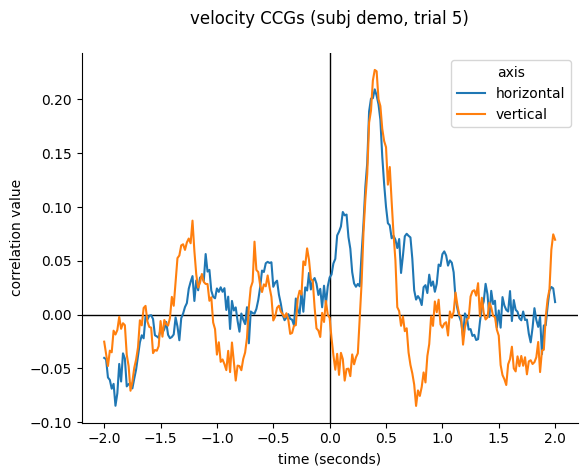

In [35]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linewidth=1)
ax.axhline(0, color='k', linewidth=1)
ax.plot(ccg_lag, ccg_x[pick_idx, :], linewidth=line_width, label="horizontal")
ax.plot(ccg_lag, ccg_y[pick_idx, :], linewidth=line_width, label="vertical")
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f"velocity CCGs (subj {participant_id}, trial {pick_a_trial})\n")
ax.set_xlabel("time (seconds)")
ax.set_ylabel("correlation value")
lgd = ax.legend(title="axis")
plt.show()


#### Plot each trial's CCGs


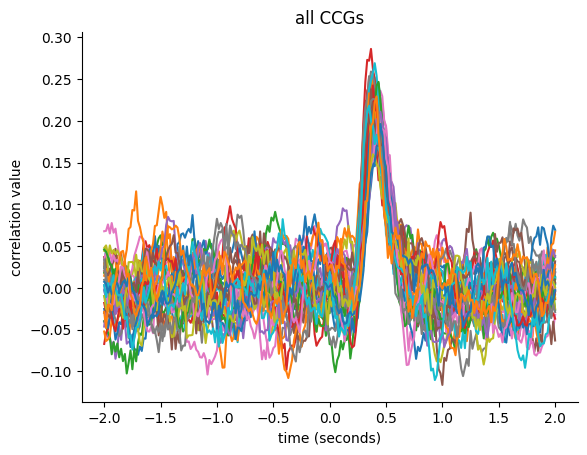

In [36]:
fig, ax = plt.subplots()
ax.plot(ccg_lag, ccg_x.T)
ax.plot(ccg_lag, ccg_y.T)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title("all CCGs")
ax.set_xlabel("time (seconds)")
ax.set_ylabel("correlation value")
plt.show()


#### Average CCGs per stimulus condition


In [37]:
ccg_df = pd.DataFrame({
    "target_width": target_width,
    "ccg_x": list(ccg_x),
    "ccg_y": list(ccg_y),
})
rows = []
for width, group in ccg_df.groupby("target_width"):
    rows.append({
        "target_width": width,
        "n_trials": len(group),
        "mean_ccg_x": np.vstack(group["ccg_x"]).mean(axis=0),
        "mean_ccg_y": np.vstack(group["ccg_y"]).mean(axis=0),
    })
expt_results = pd.DataFrame(rows).sort_values("target_width").reset_index(drop=True)

mean_ccg_x = np.vstack(expt_results["mean_ccg_x"])
mean_ccg_y = np.vstack(expt_results["mean_ccg_y"])
targ_levels = expt_results["target_width"].to_numpy(dtype=float)


#### Plot CCGs per stimulus condition


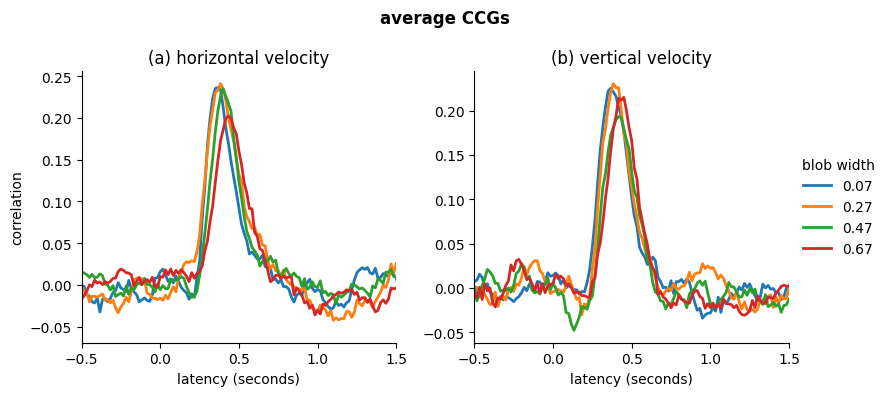

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle("average CCGs", fontweight='bold')

axes[0].plot(ccg_lag, mean_ccg_x.T, linewidth=2)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_aspect('auto')
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_title("(a) horizontal velocity")
axes[0].set_xlabel("latency (seconds)")
axes[0].set_ylabel("correlation")

axes[1].plot(ccg_lag, mean_ccg_y.T, linewidth=2)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_aspect('auto')
axes[1].set_xlim(-0.5, 1.5)
axes[1].set_title("(b) vertical velocity")
axes[1].set_xlabel("latency (seconds)")
axes[1].legend([str(v) for v in targ_levels], title="blob width", loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout()
plt.show()


**What do you notice?** Are the CCGs for the horizontal and vertical axes similar or different? Does performance change with blob width? If so, how?

#### Calculate and plot response latency

**How can we** <u>***quantitatively***</u> **compare performance across conditions?** There are three main CCG features that we can use to characterize performance:

- the peak correlation value (i.e., peak height),

- the lag value at that peak (i.e., response latency), and

- the width (e.g., the full width of the CCG at half height).

Here, let's find the peak of each CCG so that we can find the <u>**response latency**</u> per condition.


,response_latency
0.07,0.366667
0.27,0.383333
0.47,0.400000
0.67,0.433333


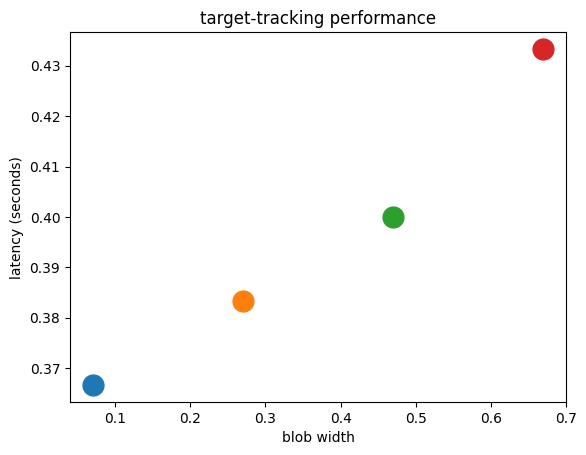

In [39]:
ccg_peak = np.max(mean_ccg_x, axis=1)
peak_frame = np.argmax(mean_ccg_x, axis=1)
response_latency = ccg_lag[peak_frame]
display(pd.DataFrame({"response_latency": response_latency}, index=targ_levels))

fig, ax = plt.subplots()
for width, latency in zip(targ_levels, response_latency):
    ax.plot(width, latency, '.', markersize=30)
ax.set_title("target-tracking performance")
ax.set_xlabel("blob width")
ax.set_ylabel("latency (seconds)")
plt.show()


## Part B. Traditional Forced Choice Experiment

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "2afc", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 144 trials.

<u>**IMPORTANT:**</u> You need to run the experiment <u>**THREE**</u> times.

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [40]:
participant_id = "demo"

# check current working directory and find files
file_info = find_participant_files(Path("2afc") / "data", participant_id)
n_files = len(file_info)


data files found:
    "demo_Bonnen2015_2afc_2025-03-24_16h55.36.408.csv"
    "demo_Bonnen2015_2afc_2025-03-24_16h58.34.387.csv"
    "demo_Bonnen2015_2afc_2025-03-24_17h14.42.856.csv"


**Confirm that all of your data files are listed above.** There should be <u>**THREE**</u> files (1 for each run).

#### Load and merge data tables


In [41]:
# load data and stack it into one table
choice_data = load_psychopy_csvs(file_info)

# display data table size
n_trials = len(choice_data)
print(f"number of trials = {n_trials}")


number of trials = 432


### Step 3. Visualize trial data

For this experiment, the stimuli were again two-dimensional Gaussian luminance blobs of varying widths. Per trial, two stimuli were shown, each in a different time interval. The reference blob (shown in the first time interval) always appeared at the center of the screen, and the horizontal position of the test blob (shown in the second time interval) varied across trials.

For each trial, PsychoPy saved the blob width, the horizontal offset of the test stimulus, and the participant's response per trial. The responses were stored as 'left' or 'right'.


In [42]:
# stash the stimulus condition per trial
stim_width = choice_data["blobWidth"].astype(float)
stim_offset = choice_data["offset"].astype(float)

# convert the response key to 1 for right and 0 for left
choice = choice_data["key_resp.keys"].astype(str).eq("right")


#### Plot the response per trial

Let's take a look at the data for each trial. Plot the horizontal offset, with the color and symbol of each marker indicating the participant's choice.


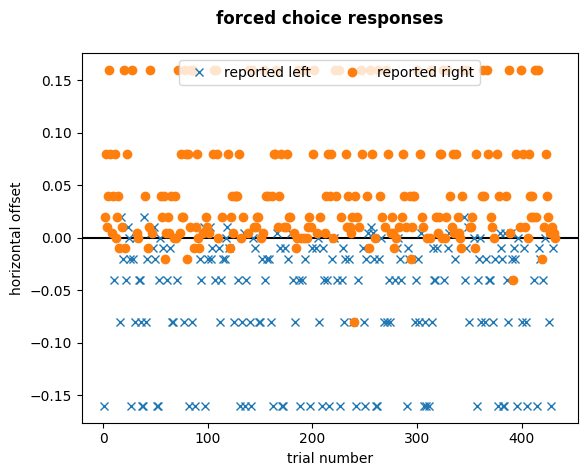

In [43]:
fig, ax = plt.subplots()
ax.set_title("forced choice responses\n", fontweight='bold')
ax.axhline(0, color='k', linewidth=1.5)

trials = np.arange(1, n_trials + 1)
ax.plot(trials[~choice], stim_offset[~choice], 'x', linewidth=1.5, label="reported left")
ax.plot(trials[choice], stim_offset[choice], 'o', linewidth=1.5, label="reported right")
ax.set_xlabel("trial number")
ax.set_ylabel("horizontal offset")
ax.legend(loc='upper center', ncol=2)
plt.show()


### Step 4. Analyze your data

#### Average responses per stimulus condition

For each combination of blob width and horizontal offset values, let's determine the probability that you reported a positive offset (i.e., that you chose 'right').


In [44]:
# average across responses per condition
choice_trials = pd.DataFrame({"response": choice, "offset": stim_offset, "blob_width": stim_width})
choice_results = (
    choice_trials
    .groupby(["offset", "blob_width"], as_index=False)
    .agg(n_trials=("response", "size"), prob_chose_pos=("response", "mean"))
)

# stash stimulus levels & counts
stim_width_levels = np.sort(choice_results["blob_width"].unique())
n_stim_width = len(stim_width_levels)


#### Plot performance per stimulus condition

Let's plot these probabilities and check out the resulting curves.


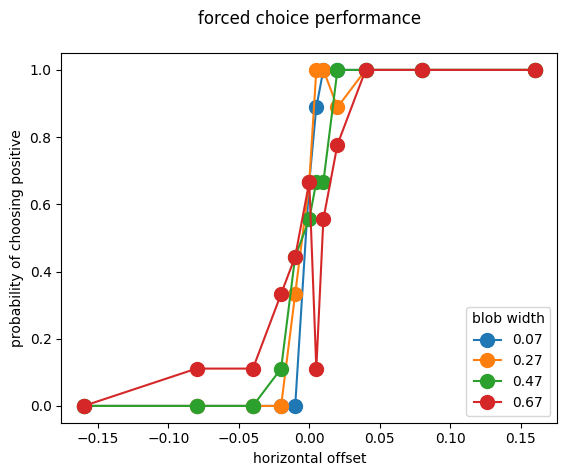

In [45]:
fig, ax = plt.subplots()
for i_width, width in enumerate(stim_width_levels):
    idx = choice_results["blob_width"].eq(width)
    ax.plot(choice_results.loc[idx, "offset"], choice_results.loc[idx, "prob_chose_pos"], '.-', markersize=20)
ax.set_title("forced choice performance\n")
ax.set_xlabel("horizontal offset")
ax.set_ylabel("probability of choosing positive")
lgd = ax.legend([str(v) for v in stim_width_levels], loc='lower right')
lgd.set_title("blob width")
plt.show()


#### Fit psychometric curves

In previous labs, we covered how to fit psychometric curves to data in order to summarize an observer's performance on a task. Let's fit this data so that we can get closer to having one number per blob width.


In [46]:
choice_params_array = np.full((n_stim_width, 4), np.nan)
choice_psignifit_results = []
for i_width, width in enumerate(stim_width_levels):
    idx = choice_results["blob_width"].eq(width)
    choice_psignifit_data = np.column_stack([
        choice_results.loc[idx, "offset"].to_numpy(dtype=float),
        choice_results.loc[idx, "prob_chose_pos"].to_numpy(dtype=float) * choice_results.loc[idx, "n_trials"].to_numpy(dtype=float),
        choice_results.loc[idx, "n_trials"].to_numpy(dtype=float),
    ])
    this_result = fit_psignifit(choice_psignifit_data, experiment_type="yes/no")
    choice_psignifit_results.append(this_result)
    choice_params_array[i_width, :] = psignifit_parameter_array(this_result, fallback_gamma=0.0, fallback_lambda=0.0)
choice_params = pd.DataFrame(
    choice_params_array,
    index=stim_width_levels,
    columns=["mu", "sigma", "gamma", "lambda"],
)
display(choice_params)


,mu,sigma,gamma,lambda
0.07,-0.001010,0.004052,1.931181e-05,5.153988e-07
0.27,-0.005891,0.006460,2.763638e-08,1.741146e-02
0.47,-0.002900,0.015617,4.202964e-06,3.348663e-06
0.67,0.001544,0.029483,3.499913e-02,5.697452e-08


#### Calculate and plot just noticeable difference (JND)

To summarize performance with a single number per blob width, let's calculate the JND associated with each width.


,JND
0.07,0.002865
0.27,0.004568
0.47,0.011043
0.67,0.020848


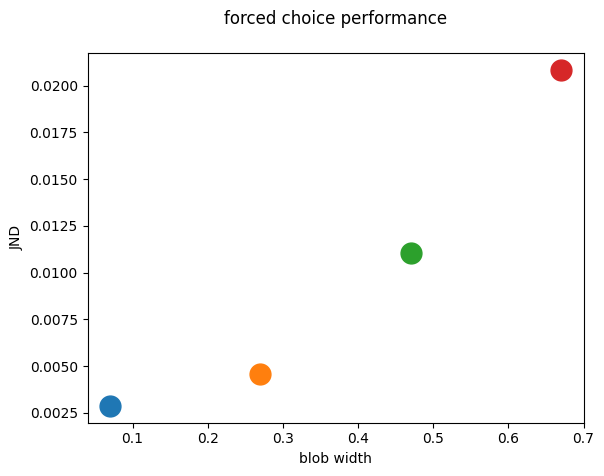

In [47]:
jnd = choice_params["sigma"] / np.sqrt(2)
display(pd.DataFrame({"JND": jnd}, index=stim_width_levels))

fig, ax = plt.subplots()
for width, this_jnd in zip(stim_width_levels, jnd):
    ax.plot(width, this_jnd, '.', markersize=30)
ax.set_title("forced choice performance\n")
ax.set_xlabel("blob width")
ax.set_ylabel("JND")
plt.show()


## Part C. Performance Comparison

We've now summarized performance on both the target-tracking and forced choice experiments. For the target-tracking task, we computed the response latency per blob width, and for the forced choice task, we computed the JND per blob width.

### Step 1. Visually compare results

In order to determine whether these experiments give us comparable results, let's first plot those two sets of numbers against one another.


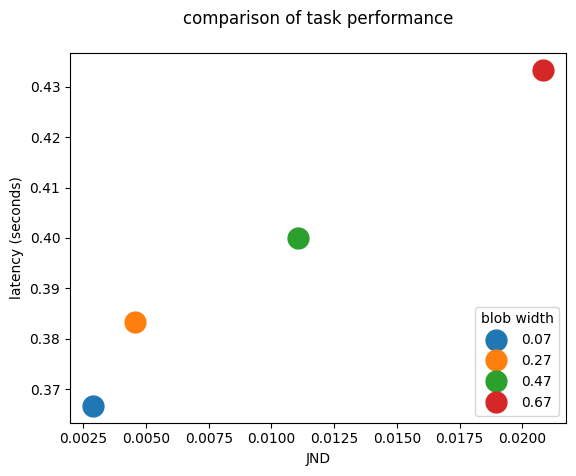

In [48]:
fig, ax = plt.subplots()
for this_jnd, latency in zip(jnd, response_latency):
    ax.plot(this_jnd, latency, '.', markersize=30)
ax.set_title("comparison of task performance\n")
ax.set_xlabel("JND")
ax.set_ylabel("latency (seconds)")
lgd = ax.legend([str(v) for v in stim_width_levels], loc='lower right')
lgd.set_title("blob width")
plt.show()


**What do you see?** Is there a systematic relationship between JND and response latency? Are these two sets of results more similar or different?

### Step 2. Quantitatively compare results

Now that we have a rough sense of how the results of these two experiments compare, let's calculate the correlation between the measured response latencies and JNDs.


In [49]:
c = float(np.corrcoef(np.asarray(jnd), np.asarray(response_latency))[0, 1])
print(f"correlation = {c:.5f}")


correlation = 0.98787


**What do you think?** Are the target-tracking and forced choice results correlated with one another? Can we use continuous psychophysics instead of the more traditional forced choice task and obtain similar results?
